In [7]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

import librosa
from IPython.display import Audio

from birdclef_2026_ml.processing.memmap_dataset import load_memmap_dataset
from birdclef_2026_ml.notebooks.notebook_utils import init_notebook
from birdclef_2026_ml.paths import load_project_paths
from birdclef_2026_ml.configs import FeatureConfig
from birdclef_2026_ml.feature_engineering.feature_extract import *

feat_cfg = FeatureConfig()
paths = load_project_paths()
init_notebook()

mpl.rcParams['axes.grid'] = False

In [8]:
train_df = pd.read_parquet(paths.train_processed) 
soundscapes = pd.read_parquet(paths.soundscapes_processed)
taxonomy = pd.read_csv(paths.taxonomy)

In [9]:
idx = {
    "Aves":130, 
    "Mammalia":0,
    "Reptilia":0,
    "Amphibia":20,
    "Insecta":50
}

## Delta features

In [10]:
def plot_delta_features(row):
    offset, duration = None, None
    pathroot = paths.train_audio_clean_trim_dir
    
    display(Audio(filename=pathroot / row["filename"]))
    y, _ = librosa.load(pathroot / row["filename"], sr=feat_cfg.sr,)
    mel_db = compute_mel_spectrogram(y, feat_cfg)
    features = extract_mel_spectrogram_features(mel_db, feat_cfg)
    delta = features["mel_spectrogram_delta"]
    delta2 = features["mel_spectrogram_delta2"]

    fig, axes = plt.subplots(3, 1, figsize=(14, 5), sharex=True)

    imgs = [
        (mel_db, "Mel Spectrogram (dB re max)", "magma", ""),
        (delta, "Delta", "RdBu", "dB/frame"),
        (delta2, "Delta-Delta", "RdBu", "dB/frame²")
    ]

    for ax, (feat, title, cmap, cbar_label) in zip(axes, imgs):
        for spine in ax.spines.values():
            spine.set_visible(True)

        im = librosa.display.specshow(
            feat,
            sr=feat_cfg.sr,
            x_axis="time",
            y_axis="mel",
            cmap=cmap,
            ax=ax
        )
        if "Spectrogram" in title:
            fig.colorbar(im, ax=ax, format="%+2.0f dB", fraction=0.3, pad=0.01, label=cbar_label)
        else:
             fig.colorbar(im, ax=ax, label=cbar_label,fraction=0.3, pad=0.01)
        ax.set_title(title)
    
    axes[0].set_xlabel("")
    axes[1].set_xlabel("")
    axes[2].set_xlabel("Time (s)")

    plt.tight_layout()
    return fig

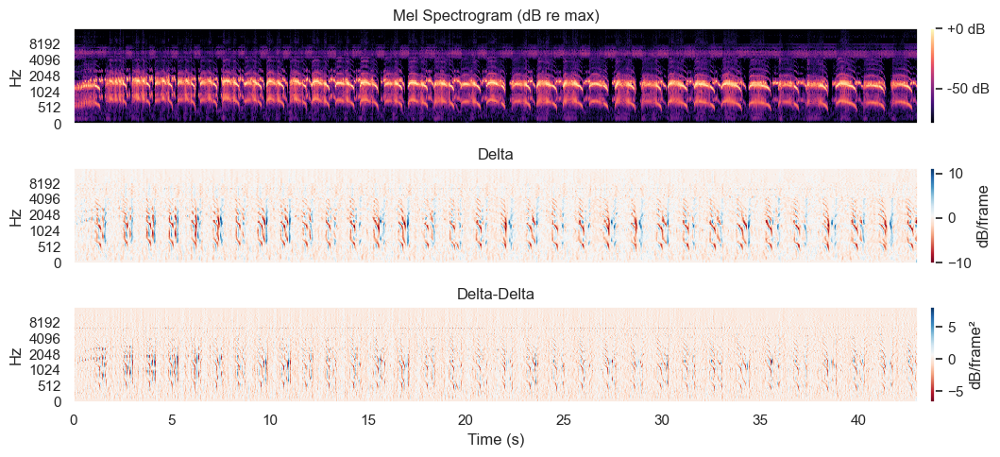

In [11]:
class_name = "Aves"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
display(Audio(filename=paths.train_audio_clean_trim_dir / row["filename"]))
fig = plot_delta_features(row)
fig.savefig(f"plots/audio_features/delta_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

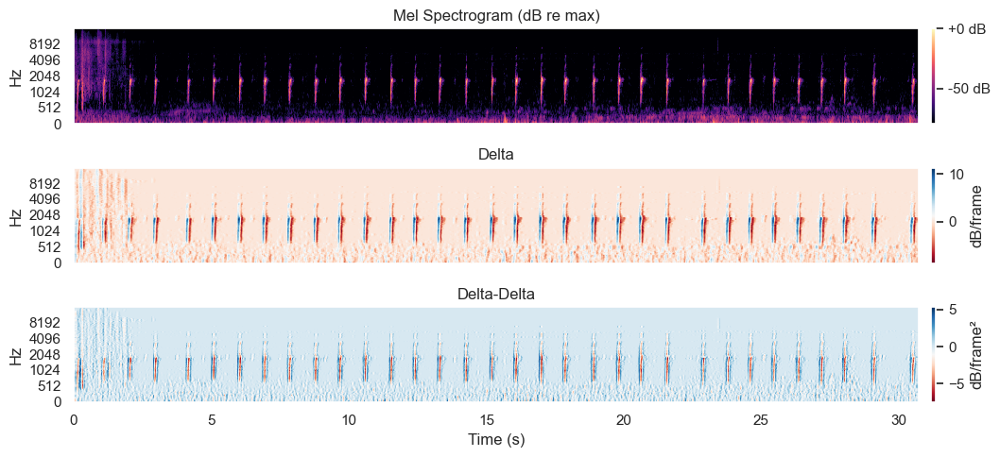

In [89]:
class_name = "Amphibia"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
display(Audio(filename=paths.train_audio_clean_trim_dir / row["filename"]))
fig = plot_delta_features(row)
fig.savefig(f"plots/audio_features/delta_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

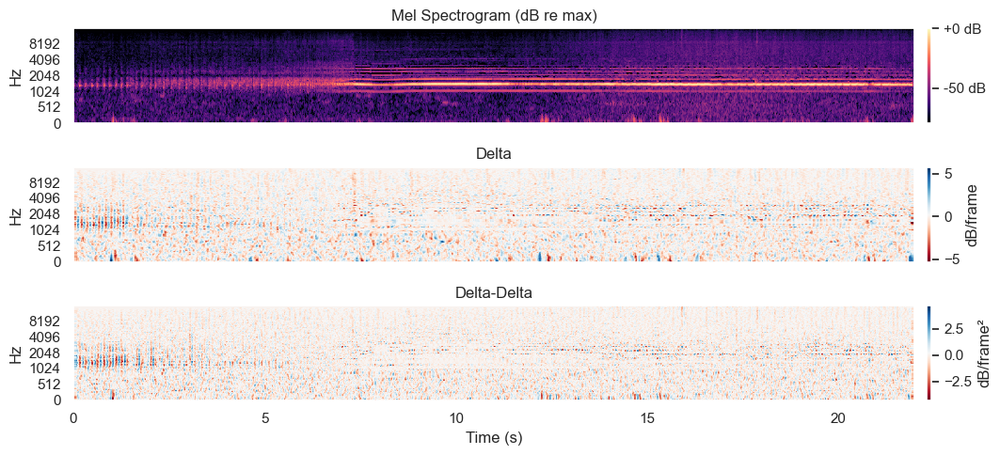

In [90]:
class_name = "Insecta"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
display(Audio(filename=paths.train_audio_clean_trim_dir / row["filename"]))
fig = plot_delta_features(row)
fig.savefig(f"plots/audio_features/delta_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

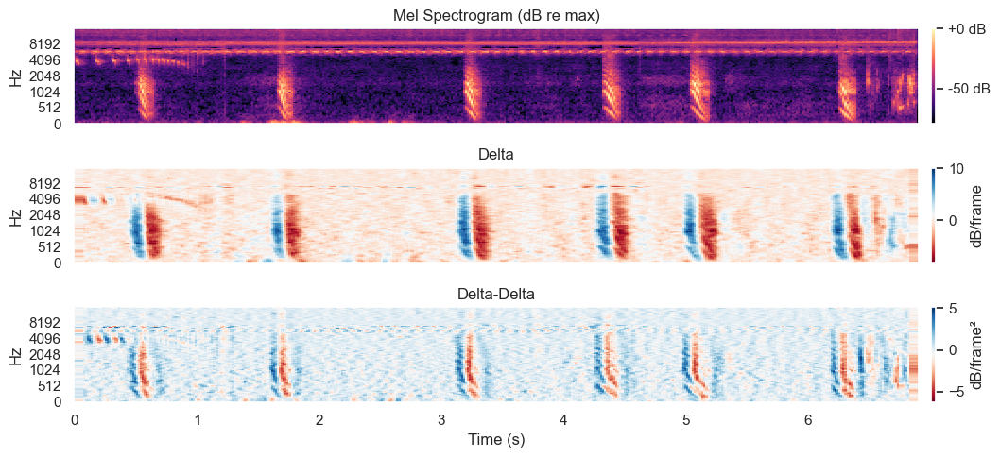

In [91]:
class_name = "Reptilia"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
display(Audio(filename=paths.train_audio_clean_trim_dir / row["filename"]))
fig = plot_delta_features(row)
fig.savefig(f"plots/audio_features/delta_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

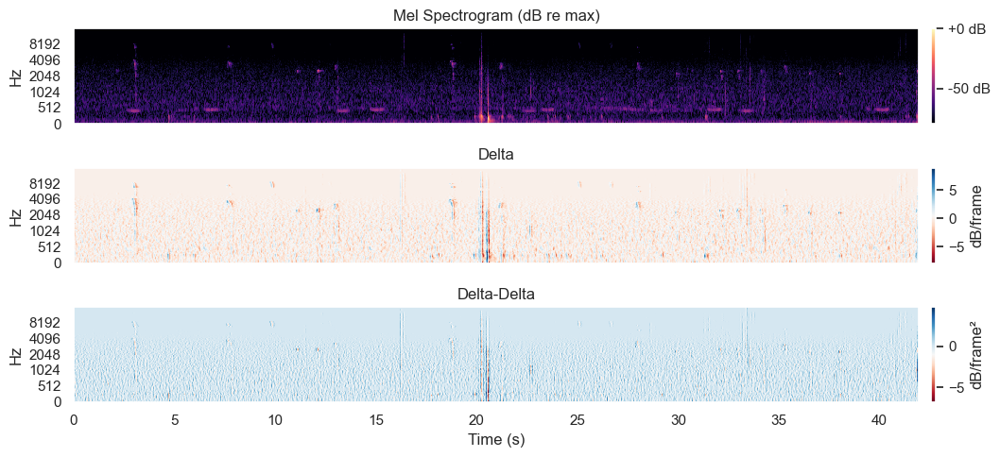

In [33]:
class_name = "Mammalia"
row = train_df[train_df["class_name"] == class_name].loc[idx[class_name]]
display(Audio(filename=paths.train_audio_clean_trim_dir / row["filename"]))
fig = plot_delta_features(row)
fig.savefig(f"plots/audio_features/delta_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

## Spectral features
- Centroid
- Bandwith
- Rolloff
- Energy proxy
- Contrast
- Flux

In [ ]:
def calc_events_rects(peaks, times):
    peaks = peaks.astype(bool)

    segments = []
    start = None

    for i, p in enumerate(peaks):
        if p and start is None:
            start = i
        elif not p and start is not None:
            segments.append((start, i))
            start = None

    if start is not None:
        segments.append((start, len(peaks)))
    
    segments_time = [
        (times[s], times[e - 1])
        for s, e in segments
    ]
    return segments_time

def plot_spectral_features(row):
    offset, duration = None, None
    pathroot = paths.train_audio_clean_trim_dir

    display(Audio(filename=pathroot / row["filename"]))

    y, _ = librosa.load(pathroot / row["filename"], sr=feat_cfg.sr)
    mel_db = compute_mel_spectrogram(y, feat_cfg)
    spectral = extract_spectral_features(mel_db, feat_cfg)
    energy = extract_energy_features(mel_db, feat_cfg)

    times = librosa.frames_to_time(
        np.arange(mel_db.shape[1]),
        sr=feat_cfg.sr,
        hop_length=feat_cfg.hop_length,
    )

    centroid_mel = spectral["spectral_centroid"][0]
    bandwidth_mel = spectral["spectral_bandwidth"][0]
    rolloff_mel = spectral["spectral_rolloff"][0]
    entropy = spectral["spectral_entropy"][0]
    contrast = spectral["spectral_contrast"]
    flux = spectral["spectral_flux"][0]
    energy_proxy = energy["spectral_energy_proxy"][0]
    burstiness = energy["burstiness"][0]
    prev_gap = energy["inter_event_prev_gap"][0]
    next_gap = energy["inter_event_next_gap"][0]

    # peak detection (binary event markers)
    threshold = np.mean(energy_proxy) + np.std(energy_proxy)
    peaks = energy_proxy > threshold

    lower_mel = np.maximum(centroid_mel - bandwidth_mel, 0)
    upper_mel = centroid_mel + bandwidth_mel

    title = f"{row['class_name']} - {row['common_name']} ({row['primary_label']})"
    fig, axes = plt.subplots(
        5, 1, figsize=(14, 12),
        sharex=True,
        gridspec_kw={"height_ratios": [1.5, 1.5, 1.5, 1.2, 1.2]}
    )

    fig.suptitle(title, y=0.95)

    # Mel spectrogram    
    im = librosa.display.specshow(
        mel_db,
        sr=feat_cfg.sr,
        hop_length=feat_cfg.hop_length,
        x_axis="time",
        y_axis="mel",
        cmap="inferno",
        ax=axes[0]
    )
    
    cbar_ax = fig.add_axes([0.99, 0.76, 0.015, 0.15])
    fig.colorbar(im, cax=cbar_ax, format='%+2.0f dB')

    segments_time = calc_events_rects(peaks, times)
    for t0, t1 in segments_time:
        axes[0].axvspan(
            t0,
            t1,
            color="white",
            alpha=0.30,
        )

    event_patch = mpatches.Patch(
        color="white",
        alpha=0.3,
        label="Event segments"
    )
    axes[0].legend(
        handles=[event_patch],
        loc="upper right",
        frameon=True
    )

    axes[0].set_title("Mel Spectrogram (dB re max)")

    # Frequency-related features
    axes[1].plot(times, centroid_mel, color="tab:blue", lw=2, label="centroid")
    axes[1].plot(times, rolloff_mel, color="tab:orange", lw=2, label="rolloff")
    axes[1].fill_between(
        times,
        lower_mel,
        upper_mel,
        color="tab:blue",
        alpha=0.3,
        label="bandwidth",
    )

    axes[1].set_ylabel("Mel bins")
    axes[1].set_title("Frequency-related Features")
    axes[1].legend(loc="upper right")

    # Temporal-energy dynamics
    energy_norm = (energy_proxy - energy_proxy.min()) / np.clip(np.ptp(energy_proxy), 1e-12, None)
    flux_norm = (flux - flux.min()) / np.clip(np.ptp(flux), 1e-12, None)
    entropy_norm = (entropy - entropy.min()) / (np.ptp(entropy) + 1e-12)

    axes[2].plot(times, energy_norm, color="#4C4C4C", lw=1.8, label="energy")
    axes[2].plot(times, flux_norm, color="#D55E00", lw=1.6, label="flux")
    axes[2].plot(times, (burstiness + 1) / 2, color="#0072B2", lw=1.6, label="burstiness")
    axes[2].plot(times, entropy_norm, color="#009E73", lw=1.8, label="entropy")

    axes[2].set_ylabel("Normalized")
    axes[2].set_title("Temporal-energy Dynamics")
    axes[2].legend(loc="upper right")

    # 4. Event structure (peaks + gaps ONLY)
    axes[3].set_title("Event Structure (Peaks & Inter-event Gaps)")
    axes[3].set_ylabel("Gap (log frames)")

    # gaps (log)
    axes[3].plot(
        times,
        np.log1p(prev_gap),
        color="tab:blue",
        lw=1.5,
        label="prev gap",
    )
    axes[3].plot(
        times,
        np.log1p(next_gap),
        color="tab:orange",
        lw=1.5,
        label="next gap",
    )

    axes[3].legend(loc="lower right")
    for ax in axes[1:4]:
        ax.grid(True, alpha=1)

    # Contrast
    im = axes[4].imshow(
        contrast,
        aspect="auto",
        origin="lower",
        cmap="inferno",
        extent=[times[0], times[-1], 0, contrast.shape[0]],
    )

    cbar_ax = fig.add_axes([0.99, 0.055, 0.015, 0.115])
    fig.colorbar(im, cax=cbar_ax)
    axes[4].set_xlabel("Time (s)")
    axes[4].set_title("Spectral Contrast")
    axes[4].set_ylabel("Contrast band")
    axes[4].set_xlabel("Time (s)")

    fig.subplots_adjust(right=0.82)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    return fig

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_15904/991376494.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


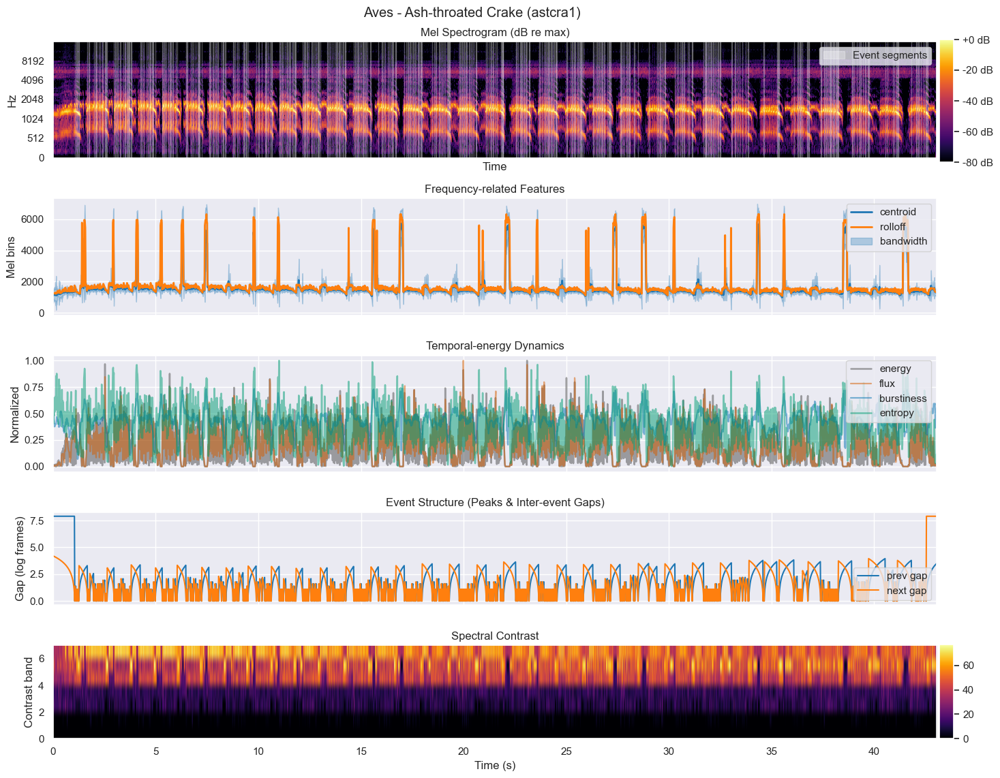

In [30]:
class_name = "Aves"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
display(Audio(filename=paths.train_audio_clean_trim_dir / row["filename"]))
fig = plot_spectral_features(row)
fig.savefig(f"plots/audio_features/spectral_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_15904/991376494.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


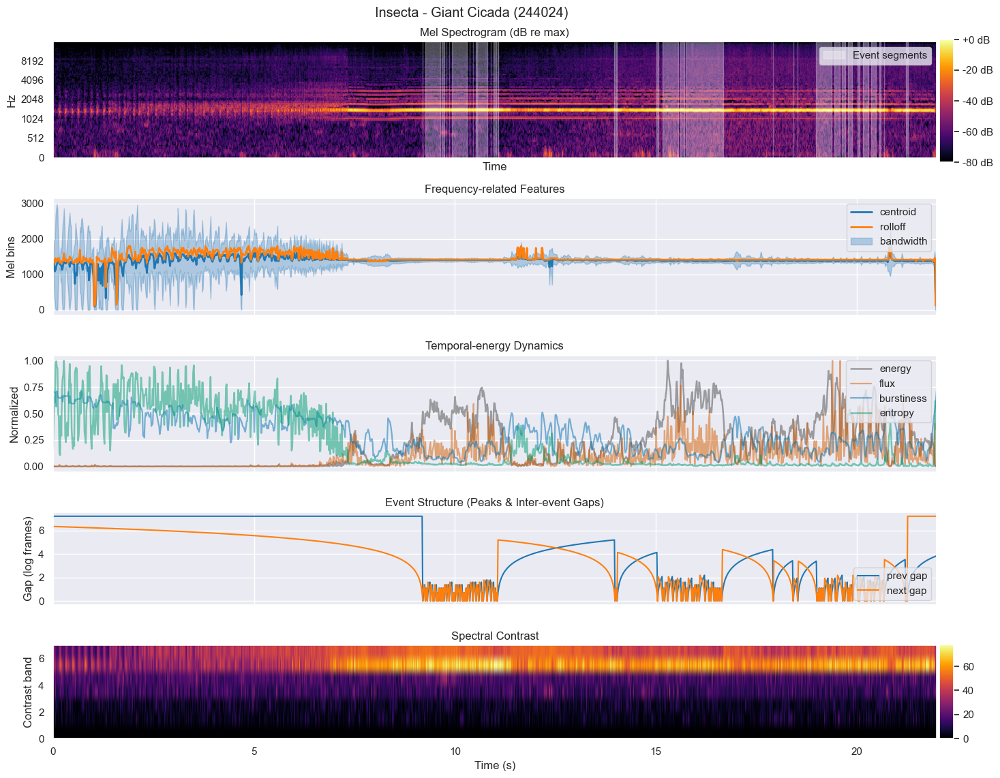

In [31]:
class_name = "Insecta"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
display(Audio(filename=paths.train_audio_clean_trim_dir / row["filename"]))
fig = plot_spectral_features(row)
fig.savefig(f"plots/audio_features/spectral_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_15904/3418095080.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


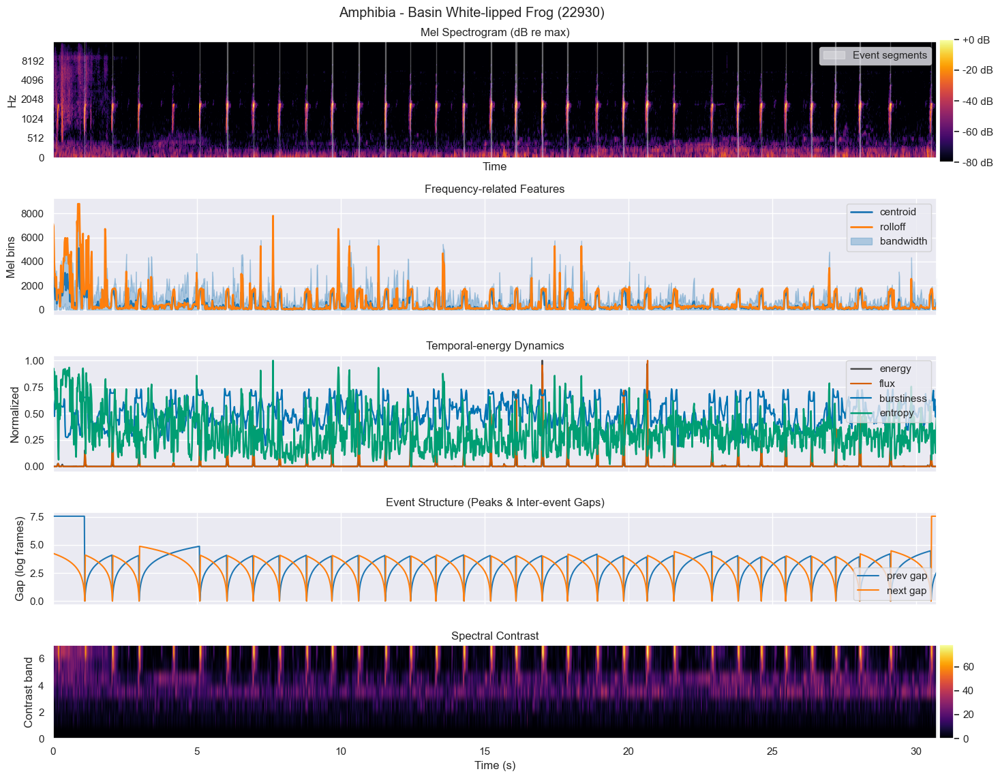

In [24]:
class_name = "Amphibia"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
display(Audio(filename=paths.train_audio_clean_trim_dir / row["filename"]))
fig = plot_spectral_features(row)
fig.savefig(f"plots/audio_features/spectral_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_15904/3418095080.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


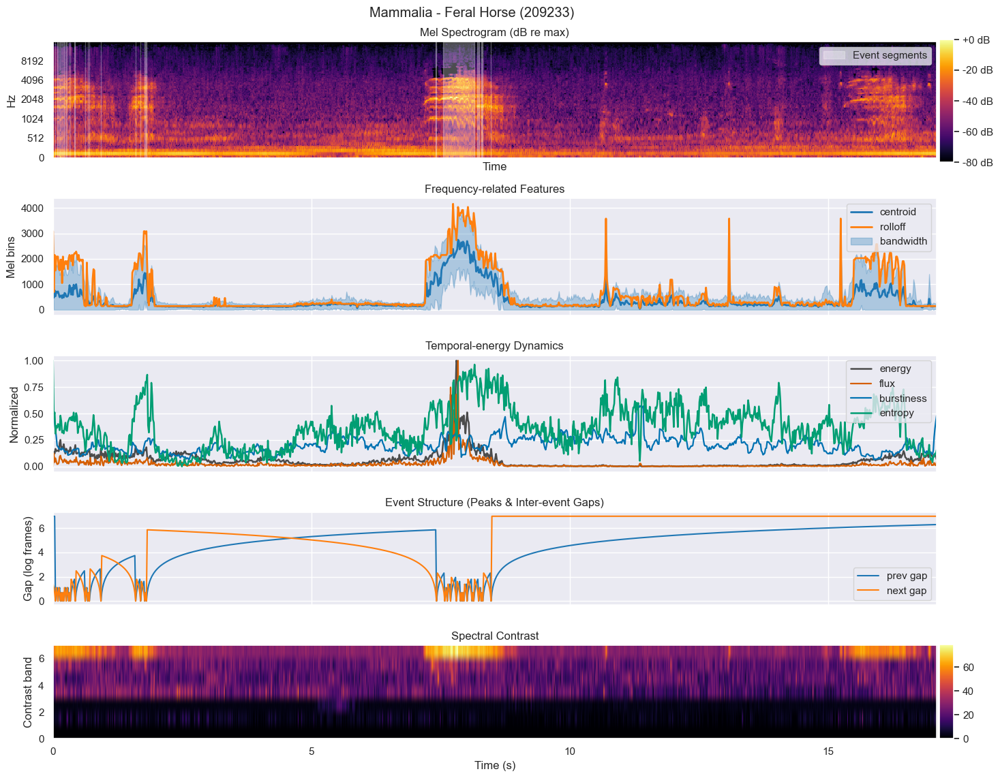

In [25]:
class_name = "Mammalia"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
display(Audio(filename=paths.train_audio_clean_trim_dir / row["filename"]))
fig = plot_spectral_features(row)
fig.savefig(f"plots/audio_features/spectral_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_15904/3418095080.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


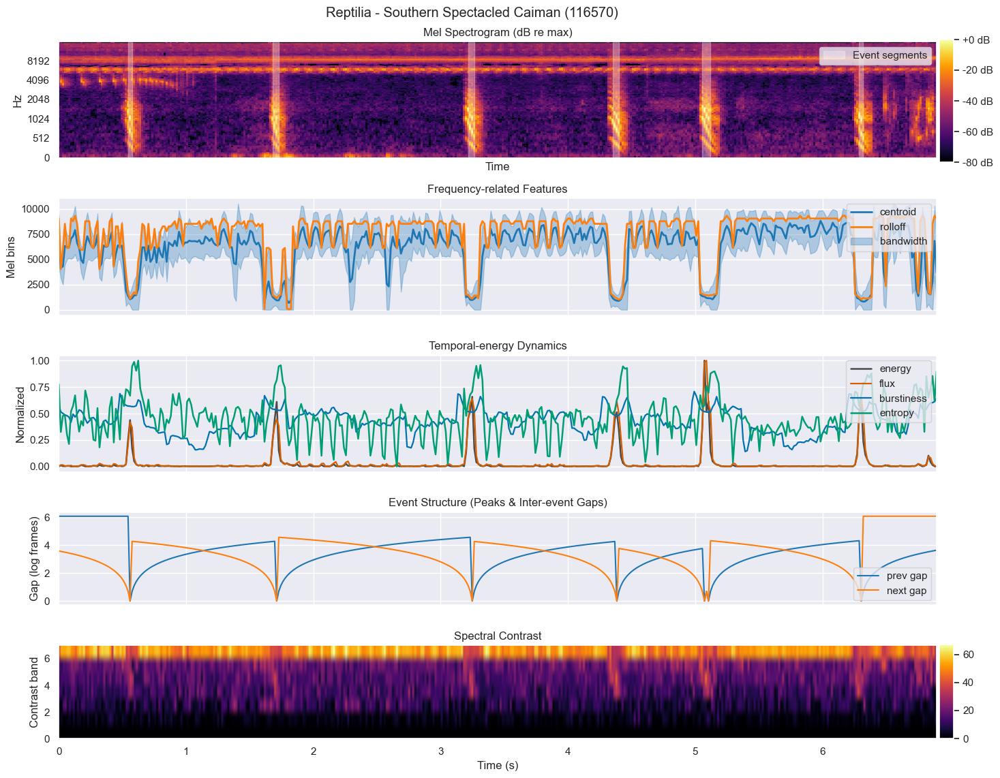

In [26]:
class_name = "Reptilia"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
display(Audio(filename=paths.train_audio_clean_trim_dir / row["filename"]))
fig = plot_spectral_features(row)
fig.savefig(f"plots/audio_features/spectral_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

## GLCM

#### Local

In [73]:
def plot_glcm_spectrogram(row):
    y, _ = librosa.load(paths.train_audio_clean_trim_dir / row["filename"], sr=feat_cfg.sr)
    mel_db = compute_mel_spectrogram(y, feat_cfg)
    glcm = extract_glcm_features(mel_db, feat_cfg)

    times = librosa.frames_to_time(
        np.arange(mel_db.shape[1]), sr=feat_cfg.sr, hop_length=feat_cfg.hop_length
    )
    title = f"{row['class_name']} - {row['common_name']} ({row['primary_label']})"
    fig, axes = plt.subplots(
        6, 1, figsize=(14, 10), sharex=True, gridspec_kw={"height_ratios": [1.2, 0.9, 0.9, 0.9, 0.9, 1.2]}
    )
    fig.suptitle(title)

    # Spectrogram
    im = librosa.display.specshow(mel_db, sr=feat_cfg.sr, x_axis="time", y_axis="mel", ax=axes[0])
    # divider = make_axes_locatable(axes[0])
    # cax = divider.append_axes("right", size="3%", pad=0.15)
    fig.subplots_adjust(0.835)
    cbar_ax = fig.add_axes([0.95, 0.81, 0.015, 0.115])
    fig.colorbar(im, cax=cbar_ax, format='%+2.0f dB')
    axes[0].set_title("Mel Spectrogram (dB re max)")

    # Time-direction GLCM features
    axes[1].plot(times, glcm["glcm_time_contrast"][0], label="contrast")
    axes[1].plot(times, glcm["glcm_time_entropy"][0], label="entropy")
    axes[1].set_title("GLCM Time Features")
    axes[1].legend(loc="upper left")

    axes[2].plot(times, glcm["glcm_time_homogeneity"][0], label="homogeneity")
    axes[2].plot(times, glcm["glcm_time_energy"][0], label="energy")
    axes[2].set_title("GLCM Time Structure")
    axes[2].legend(loc="upper left")

    # Frequency-direction GLCM features
    axes[3].plot(times, glcm["glcm_freq_contrast"][0], label="contrast")
    axes[3].plot(times, glcm["glcm_freq_entropy"][0], label="entropy")
    axes[3].set_title("GLCM Frequency Features")
    axes[3].legend(loc="upper left")

    axes[4].plot(times, glcm["glcm_freq_homogeneity"][0], label="homogeneity")
    axes[4].plot(times, glcm["glcm_freq_energy"][0], label="energy")
    axes[4].set_title("GLCM Frequency Structure")
    axes[4].legend(loc="upper left")

    # Heatmap
    features = np.vstack([glcm[k] for k in glcm])
    im=axes[5].imshow(features, aspect="auto", origin="lower", cmap="viridis", vmin=0, vmax=3,
                        extent=[times[0], times[-1], 0, features.shape[0]])
    axes[5].set_yticks(
        range(8),
        ["t_contrast", "t_entropy", "t_homogeneity", "t_energy", "f_contrast", "f_entropy", "f_homogeneity", "f_energy"]
    )
    axes[5].set_title("GLCM Feature Map (Time × Feature)")
    axes[5].set_xlabel("Time (s)")
    cbar_ax = fig.add_axes([0.95, 0.065, 0.015, 0.115])
    fig.colorbar(im, cax=cbar_ax)

    plt.tight_layout()
    return fig

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_41711/514804892.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


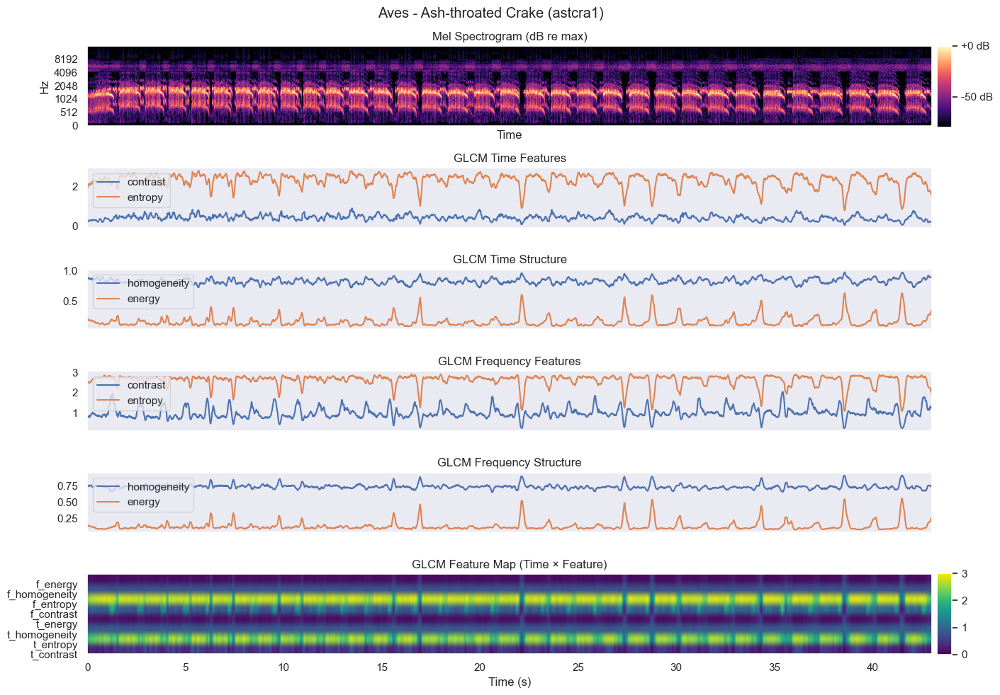

In [74]:
class_name="Aves"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
fig = plot_glcm_spectrogram(row)
fig.savefig(f"plots/audio_features/glcm_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_41711/514804892.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


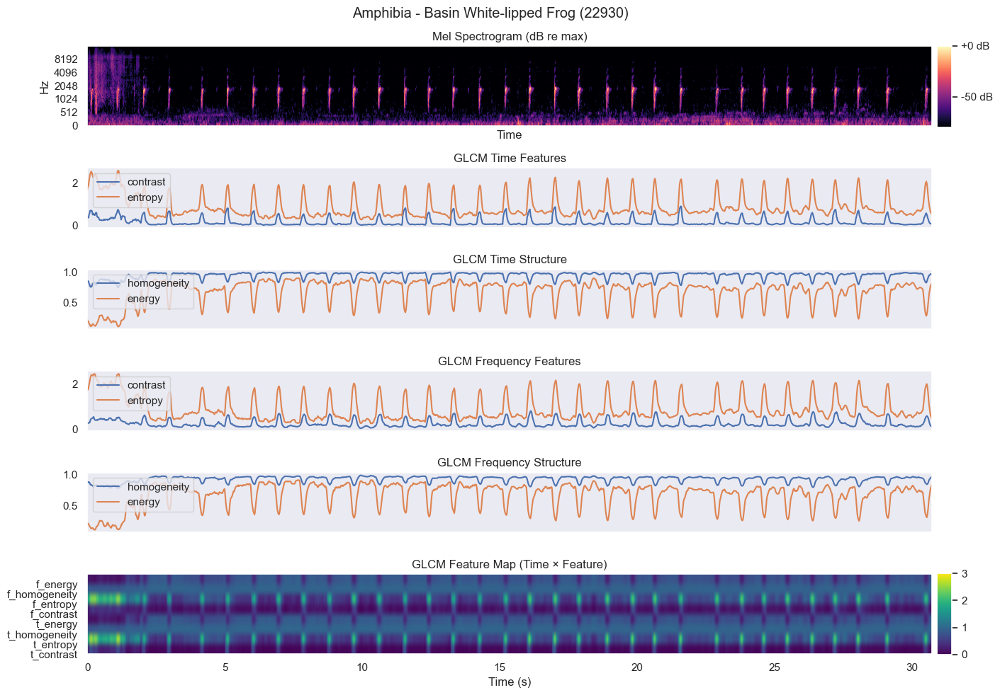

In [75]:
class_name="Amphibia"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
fig = plot_glcm_spectrogram(row)
fig.savefig(f"plots/audio_features/glcm_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_41711/514804892.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


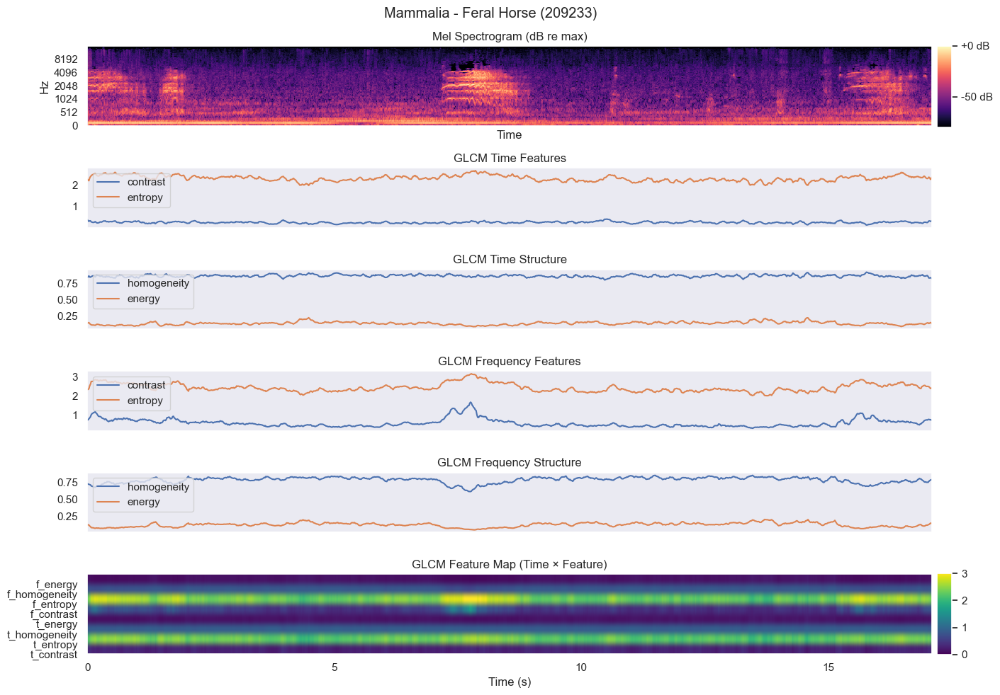

In [76]:
class_name="Mammalia"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
fig = plot_glcm_spectrogram(row)
fig.savefig(f"plots/audio_features/glcm_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_41711/514804892.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


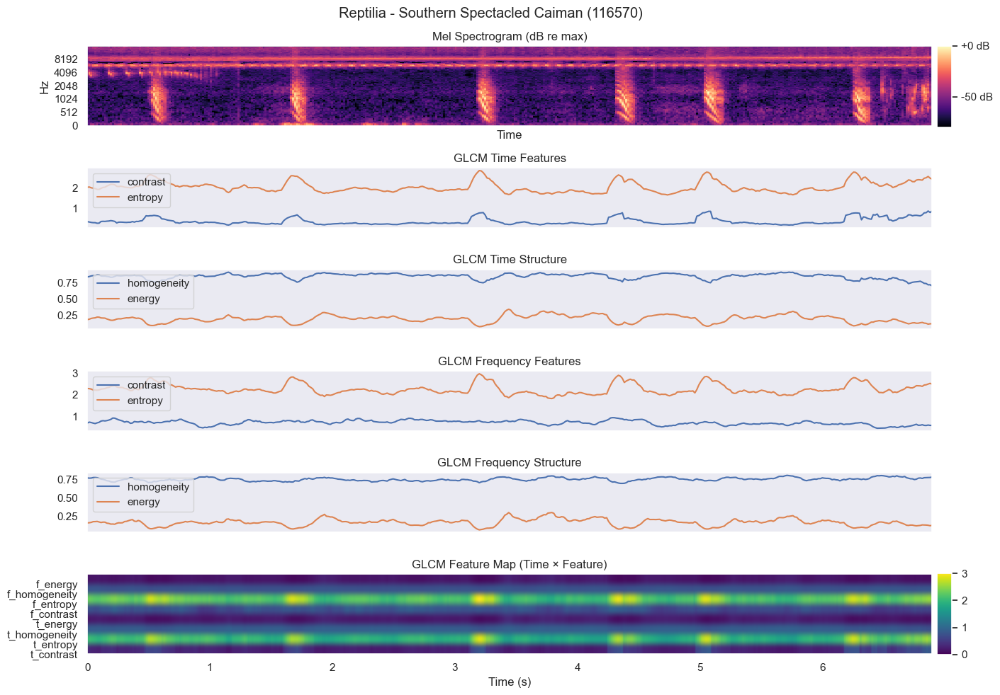

In [77]:
class_name="Reptilia"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
fig = plot_glcm_spectrogram(row)
fig.savefig(f"plots/audio_features/glcm_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_41711/514804892.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


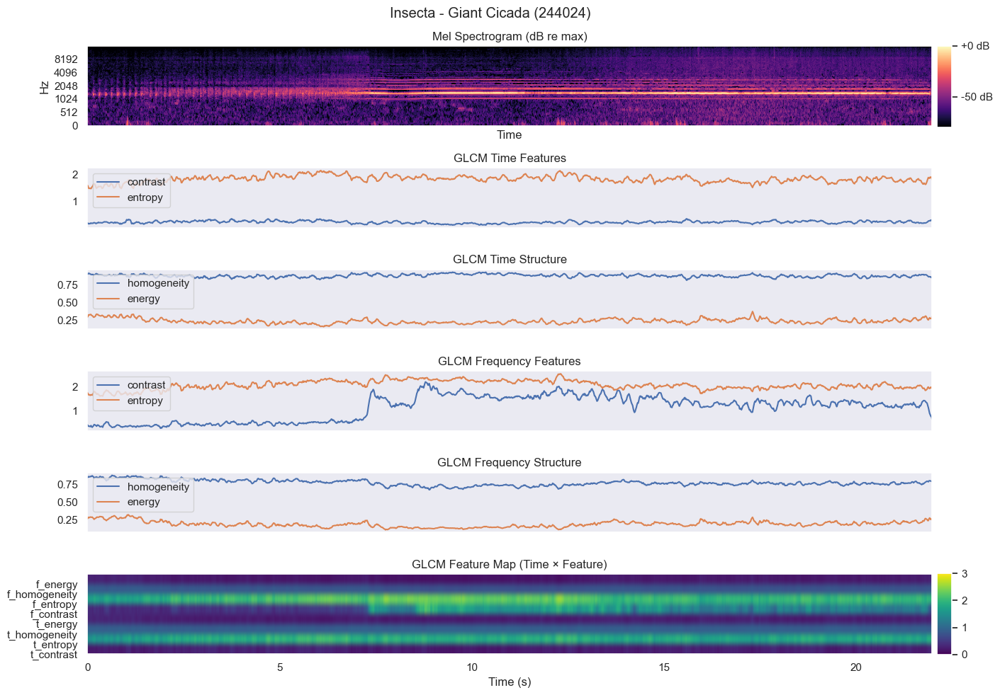

In [78]:
class_name="Insecta"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
fig = plot_glcm_spectrogram(row)
fig.savefig(f"plots/audio_features/glcm_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

## LBP

#### Local

In [87]:
def plot_lbp_heatmap(row):
    y, _ = librosa.load(
        paths.train_audio_clean_trim_dir / row["filename"],
        sr=feat_cfg.sr
    )

    mel_db = compute_mel_spectrogram(y, feat_cfg)
    lbp_hist = extract_lbp_features(mel_db, feat_cfg)["lbp_hist"]

    # Entropy-based complexity
    complexity = -np.sum(
        lbp_hist * np.log(lbp_hist + 1e-10),
        axis=0
    )

    hop_sec = feat_cfg.hop_length / feat_cfg.sr
    times = np.arange(lbp_hist.shape[1]) * hop_sec

    fig, ax = plt.subplots(figsize=(14, 5))

    im = ax.imshow(
        lbp_hist,
        aspect="auto",
        origin="lower",
        cmap="viridis",
        extent=[times[0], times[-1], 0, lbp_hist.shape[0]],
        vmin=0,
        vmax=1
    )

    # Secondary axis for entropy
    ax2 = ax.twinx()

    ax2.plot(
        times,
        complexity,
        color="white",
        linewidth=1.5,
        label="Entropy"
    )

    # Labels
    #ax.set_title("LBP Pattern Distribution Over Time")

    title = f"{row['class_name']} - {row['common_name']} ({row['primary_label']})"
    ax.set_title(title)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("LBP Pattern Index")

    ax2.set_ylabel("Entropy")

    # Styling
    ax.grid(False)
    ax2.grid(False)

    # Keep clean frame
    for spine in ax.spines.values():
        spine.set_visible(True)

    for spine in ax2.spines.values():
        spine.set_visible(False)

    # Colorbar
    fig.subplots_adjust(right=0.9)
    cbar_ax = fig.add_axes([0.99, 0.13, 0.015, 0.8])
    fig.colorbar(im, cax=cbar_ax, format='%+2.0f dB')
    cbar = fig.colorbar(im, cax=cbar_ax)

    cbar.set_label("Normalized LBP Frequency")
    ax2.legend(loc="upper right", frameon=True)
    plt.tight_layout()

    return fig

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_41711/2749247905.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


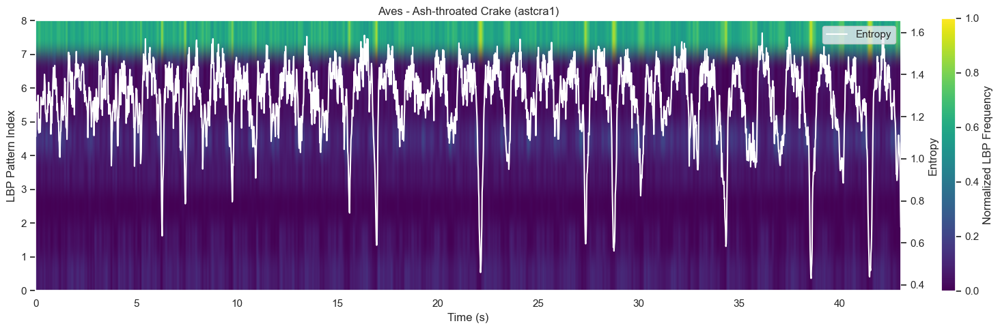

In [88]:
class_name="Aves"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
fig = plot_lbp_heatmap(row)
fig.savefig(f"plots/audio_features/lbp_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_41711/2749247905.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


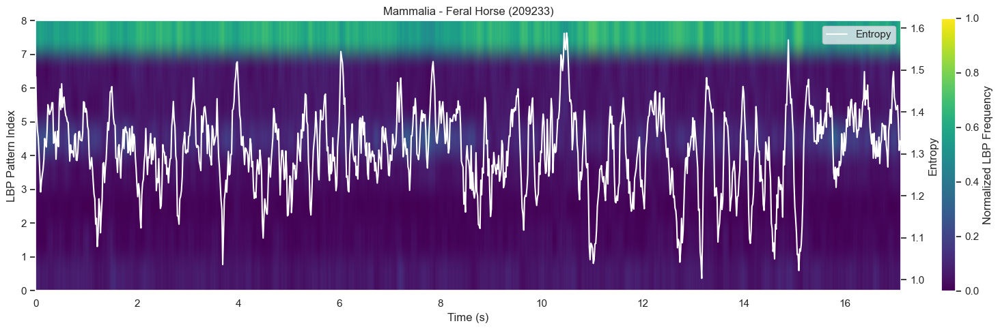

In [89]:
class_name="Mammalia"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
fig = plot_lbp_heatmap(row)
fig.savefig(f"plots/audio_features/lbp_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_41711/2749247905.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


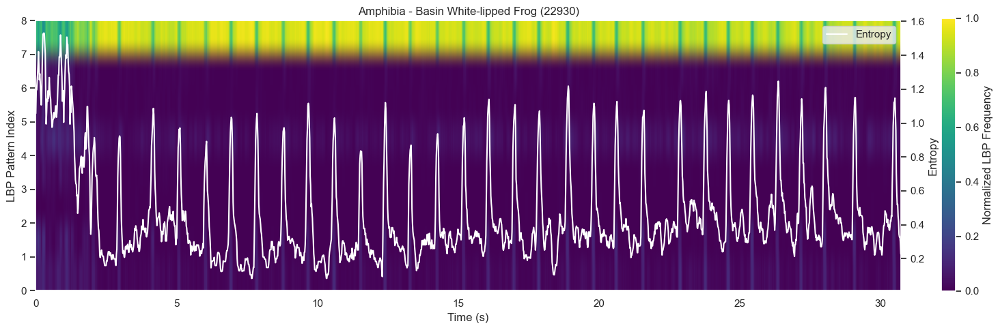

In [90]:
class_name="Amphibia"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
fig = plot_lbp_heatmap(row)
fig.savefig(f"plots/audio_features/lbp_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_41711/2749247905.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


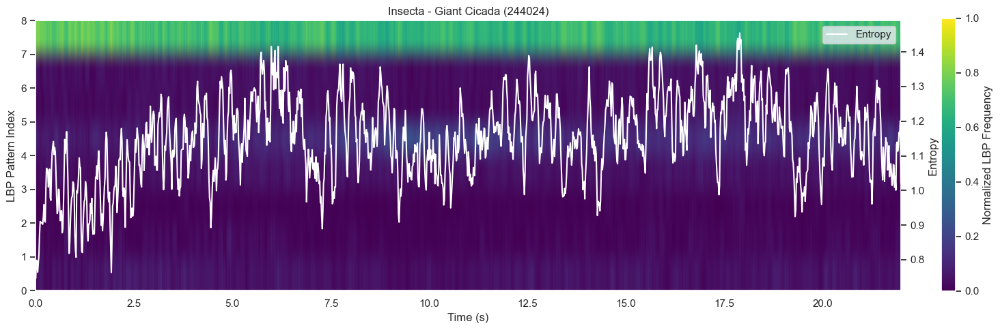

In [91]:
class_name="Insecta"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
fig = plot_lbp_heatmap(row)
fig.savefig(f"plots/audio_features/lbp_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_41711/2749247905.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


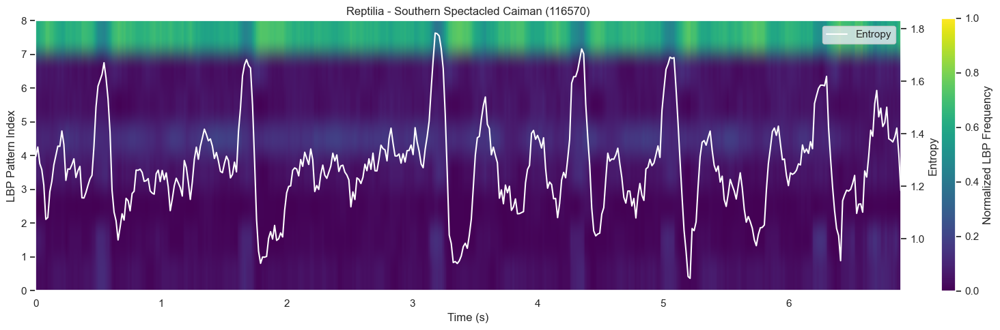

In [92]:
class_name="Reptilia"
row = train_df[train_df["class_name"] == class_name].iloc[idx[class_name]]
fig = plot_lbp_heatmap(row)
fig.savefig(f"plots/audio_features/lbp_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")